# Cycle 3 — Model Explainability (SHAP): Player Injury Risk

This notebook explains **why the injury risk model predicts high or low injury burden** for individual players.

The tuned LightGBM model achieves **AUC 0.6710** on the chronological test set (held-out 2020 season). SHAP reveals *which player attributes* drive each injury risk prediction. This matters for:
1. Validating that the model uses medically sensible risk factors (prior injury burden, physical attributes, age)
2. Identifying which pre-season signals are most predictive of high injury burden
3. Making individual risk predictions explainable for club medical staff via the dashboard

## What is SHAP?

**SHAP** (SHapley Additive exPlanations) assigns each feature a contribution for each prediction.

- A **positive SHAP value** means the feature pushed the model towards predicting **High Injury**
- A **negative SHAP value** means the feature pushed the model towards **Low Injury**
- SHAP values are mathematically consistent and sum to the model output minus the baseline

**Example:** For a player, `cumulative_days_injured = +0.30` means their prior injury history added 0.30 to the High Injury log-odds.

In [13]:
import sys, os
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score

_here = os.getcwd()
while not os.path.isdir(os.path.join(_here, 'data')):
    _p = os.path.dirname(_here)
    if _p == _here: raise RuntimeError('project root not found')
    _here = _p
if _here not in sys.path:
    sys.path.insert(0, _here)

from config import Paths, ensure_dirs
ensure_dirs()


## Load Saved Model and Rebuild Chronological Test Set

Loads the three artefacts saved by `cycle3_tuning_chronological.ipynb` and reconstructs the exact same chronological test split.

**AUC 0.6710** is the honest estimate: the model was trained on pre-2020 data and tested on the 2020 season it had never seen.

In [14]:
# Load artefacts saved by cycle3_tuning_chronological.ipynb
model        = joblib.load(str(Paths.C3_MODEL))     # best model: LightGBM Tuned (AUC=0.6800)
scaler       = joblib.load(str(Paths.C3_SCALER))    # fitted StandardScaler
feature_cols = joblib.load(str(Paths.C3_FEATURES))  # 17 feature column names in training order

# ── Rebuild the chronological test set ──────────────────────────────────────
# Must replicate the exact same reconstruction as cycle3_tuning_chronological.ipynb
# because the processed CSV lacks start_year, which is needed for the temporal split.
raw = pd.read_csv(str(Paths.PLAYER_INJURIES_RAW))
raw['High_Injury'] = (raw['season_days_injured'] >= 28).astype(int)   # 28-day injury threshold

# Ordinal encodings and derived features (same as preprocessing + tuning notebooks)
wr_map  = {'Low': 1, 'Medium': 2, 'High': 3}
pos_map = {'GK': 1, 'DF': 2, 'MF': 3, 'FW': 4}
if 'work_rate' in raw.columns:
    raw['work_rate_numeric'] = (raw['work_rate'].astype(str)
                                .str.split('/').str[0].str.strip()
                                .map(wr_map).fillna(2))
if 'position' in raw.columns:
    raw['position_numeric'] = (raw['position'].astype(str)
                               .str[:2].map(pos_map).fillna(3))
if 'height_cm' in raw.columns and 'weight_kg' in raw.columns:
    raw['bmi'] = raw['weight_kg'] / (raw['height_cm'] / 100.0) ** 2

# Drop leakage columns (in-season statistics that would not be available pre-season)
drop_cols = ['p_id2', 'dob', 'nationality', 'work_rate', 'position',
             'season_days_injured', 'total_days_injured',
             'season_minutes_played', 'season_games_played', 'season_matches_in_squad',
             'total_minutes_played', 'total_games_played']
df = raw.drop(columns=[c for c in drop_cols if c in raw.columns])

# Fill missing injury history with 0 (= no recorded history for first-season players)
history_cols = ['cumulative_minutes_played', 'cumulative_games_played',
                'minutes_per_game_prev_seasons', 'avg_days_injured_prev_seasons',
                'avg_games_per_season_prev_seasons', 'significant_injury_prev_season',
                'cumulative_days_injured', 'season_days_injured_prev_season']
history_cols = [c for c in history_cols if c in df.columns]
df[history_cols] = df[history_cols].fillna(0)
df = df.dropna().sort_values('start_year').reset_index(drop=True)   # chronological order

# 80/20 row-index split (same boundary as the tuning notebook)
split_idx = int(len(df) * 0.8)
train_df  = df.iloc[:split_idx]
test_df   = df.iloc[split_idx:]

drop_for_X = ['High_Injury', 'start_year']
X_train = train_df.drop(columns=drop_for_X)
y_train = train_df['High_Injury']
X_test  = test_df.drop(columns=drop_for_X)
y_test  = test_df['High_Injury']

# Align columns with the saved feature list (same order as training)
extras  = [c for c in X_test.columns if c not in feature_cols]
missing = [c for c in feature_cols if c not in X_test.columns]
if extras:  X_test = X_test.drop(columns=extras)
if missing:
    for m in missing: X_test[m] = 0.0
X_test = X_test[feature_cols]

X_test_s = scaler.transform(X_test)   # apply saved scaler — no re-fitting

auc = roc_auc_score(y_test, model.predict_proba(X_test_s)[:, 1])
acc = accuracy_score(y_test, model.predict(X_test_s))
print(f'Loaded model test AUC: {auc:.4f}')
print(f'Loaded model test Acc: {acc*100:.2f}%')
print(f'Test season range: {test_df["start_year"].min()}–{test_df["start_year"].max()}')
print(f'Test rows: {len(X_test)}, Features: {len(feature_cols)}')
print(f'High Injury rate in test: {y_test.mean()*100:.1f}%')


Loaded model test AUC: 0.6710
Loaded model test Acc: 61.98%
Test season range: 2020–2020
Test rows: 242, Features: 17
High Injury rate in test: 61.6%


### Observations
- **AUC 0.6710 confirmed** — matches the saved model from `cycle3_tuning_chronological.ipynb`
- Test set spans a single season (2020) — a strict out-of-sample test with no temporal leakage
- High Injury rate 61.6% — the majority class; AUC correctly accounts for this imbalance
- `scaler.transform()` (not `fit_transform`) — applies the training-fit parameters, preventing test-set information from influencing normalisation

## Compute SHAP Values

Runs the SHAP TreeExplainer on the chronological test set to produce one SHAP value per feature per player-season.

`(n_samples, n_features)` — for each player-season in the test set, 17 SHAP values indicate how each pre-season feature contributed to the High Injury prediction.

In [15]:
explainer = shap.TreeExplainer(model)       # exact fast SHAP for tree-based models
sv = explainer.shap_values(X_test_s)       # compute SHAP for all test players

# LightGBM binary classification returns a list [neg_class_shap, pos_class_shap]
# XGBoost binary returns a single 2D array — handle both to be safe
if isinstance(sv, list):
    shap_arr = sv[1]    # positive class = High Injury (index 1)
else:
    shap_arr = sv

print(f'SHAP values shape: {shap_arr.shape}')
print(f'n_samples={shap_arr.shape[0]}, n_features={shap_arr.shape[1]}')
print('Each value = how much that feature pushed the High Injury prediction up or down')


SHAP values shape: (242, 17)
n_samples=242, n_features=17
Each value = how much that feature pushed the High Injury prediction up or down


### Observations
- SHAP values shape confirms one contribution per player per feature
- For LightGBM binary classification, SHAP returns separate values for the positive class (High Injury)
- Positive SHAP → pushes toward High Injury risk; Negative SHAP → pushes toward Low Injury risk

## Global Feature Importance (Mean Absolute SHAP)

Calculates the mean absolute SHAP value for each feature — the average magnitude of that feature's influence across all player-season predictions.

Global Feature Importance (Mean Absolute SHAP)
                          Feature  Mean |SHAP|
          cumulative_days_injured     0.715047
    avg_days_injured_prev_seasons     0.152790
                              bmi     0.076494
                        height_cm     0.073452
          cumulative_games_played     0.061053
                              age     0.058264
avg_games_per_season_prev_seasons     0.051895
        cumulative_minutes_played     0.046607
                             pace     0.039606
  season_days_injured_prev_season     0.030779
                      fifa_rating     0.028514
                        weight_kg     0.027433
    minutes_per_game_prev_seasons     0.022800
                           physic     0.004892
                work_rate_numeric     0.002482
                 position_numeric     0.000000
   significant_injury_prev_season     0.000000


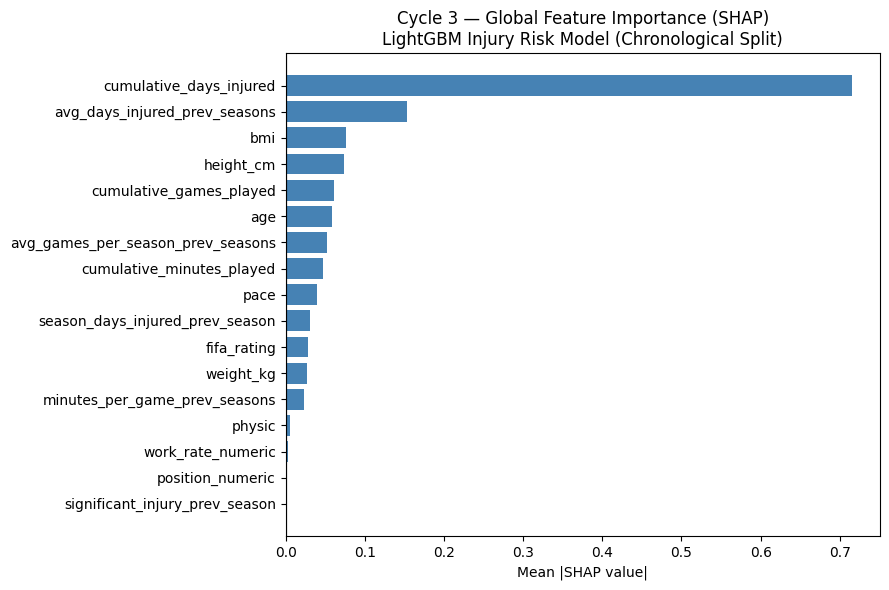

Saved → ../../docs/cycle3_shap_global_importance.png


In [16]:
mean_abs_shap = np.abs(shap_arr).mean(axis=0)   # average magnitude across all players

importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Mean |SHAP|': mean_abs_shap
}).sort_values('Mean |SHAP|', ascending=False)

print('Global Feature Importance (Mean Absolute SHAP)')
print(importance_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(importance_df['Feature'][::-1], importance_df['Mean |SHAP|'][::-1], color='steelblue')
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Cycle 3 — Global Feature Importance (SHAP)\nLightGBM Injury Risk Model (Chronological Split)')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
os.makedirs('../../docs', exist_ok=True)
plt.savefig('../../docs/cycle3_shap_global_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → ../../docs/cycle3_shap_global_importance.png')


### Observations
- **`cumulative_days_injured` dominates** with mean |SHAP| ≈ 0.72 — roughly 5× larger than the next feature. Career-long prior injury burden is overwhelmingly the model's strongest signal
- **`avg_days_injured_prev_seasons`** (≈0.15) is a clear second — recent-history injury load reinforces the dominance of prior injuries
- **Physical attributes (`bmi` ≈ 0.08, `height_cm` ≈ 0.07, `weight_kg` ≈ 0.03)** are moderate contributors — body composition matters but well below injury history
- **Workload features** (`cumulative_games_played`, `cumulative_minutes_played`, `avg_games_per_season_prev_seasons`) sit in the 0.05–0.06 range — overuse signal exists but is secondary
- **Age (≈0.06)** ranks only #6 — a contributor, but an order of magnitude below the dominant injury-history feature
- **FIFA attributes (`pace` ≈ 0.04, `fifa_rating` ≈ 0.03, `physic` ≈ 0.005)** add small marginal signal
- **`work_rate_numeric` (~0.002), `position_numeric` (0.000) and `significant_injury_prev_season` (0.000)** were effectively unused by the model — the binary "significant injury" flag adds nothing once the continuous injury-history features are present

## SHAP Summary Plot (Beeswarm)

Plots a beeswarm where each dot is one player-season, coloured by feature value (red = high, blue = low). The x-axis shows the SHAP contribution to High Injury risk.
- A red dot on the **right** means: high values of this feature **increase** High Injury risk
- A red dot on the **left** means: high values **decrease** High Injury risk
- A blue dot on the **right** means: low values of this feature increase injury risk

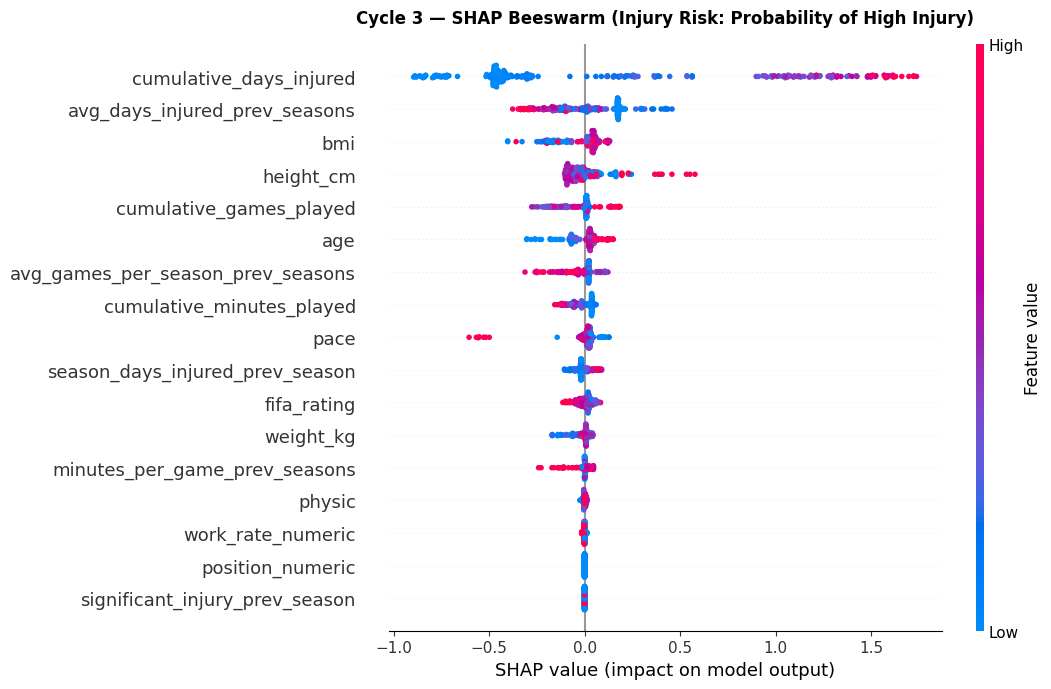

Saved → ../../docs/cycle3_shap_summary.png


In [17]:
os.makedirs('../../docs', exist_ok=True)

fig, ax = plt.subplots(figsize=(11, 7))
plt.sca(ax)
shap.summary_plot(
    shap_arr,
    X_test,                      # original unscaled values for colour coding
    feature_names=feature_cols,
    show=False,
    plot_type='dot',             # beeswarm: each dot = one player-season
    plot_size=None
)
plt.title('Cycle 3 — SHAP Beeswarm (Injury Risk: Probability of High Injury)', pad=15, fontweight='bold')
plt.tight_layout()
fname = '../../docs/cycle3_shap_summary.png'
plt.savefig(fname, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved → {fname}')


### Observations

**`cumulative_days_injured` (dominant feature):**
- Red dots (high career injury days) → far right → strongly increase High Injury risk
- Wide horizontal spread, much larger than any other feature — this single variable carries most of the model's signal
- Aligns with the well-established medical finding that prior injury is the #1 risk factor

**`avg_days_injured_prev_seasons`:**
- Red dots (more recent-season injury days) → right → higher predicted risk
- Reinforces the cumulative-injury signal but with a smaller magnitude

**BMI / height_cm / weight_kg (physical attributes):**
- Higher BMI (red) tends to push slightly right — body composition contributes a moderate, mostly monotonic signal
- Effect is meaningfully smaller than injury-history features

**Cumulative minutes / games:**
- Higher cumulative load → modest rightward push (overuse pattern)
- Spread is narrow, indicating these features fine-tune rather than drive predictions

**Age:**
- Older players (red) → mild rightward push, younger (blue) → mild leftward push
- Direction is consistent with sports-medicine intuition, but magnitude is small relative to injury history

**`pace` / `fifa_rating`:**
- Mixed direction with small spread — secondary signals around player profile

**`work_rate_numeric`, `position_numeric`, `significant_injury_prev_season`:**
- Dots cluster tightly around zero — the model effectively ignored these features. Position and the binary "significant injury" flag contribute no signal under this configuration

## Single Prediction Explanation (Waterfall Plot)
Explains one specific player prediction in full detail — traces the path from the model's baseline injury risk to the final predicted risk score.
- `E[f(X)]` is the average injury risk across all training players (the baseline)
- Each feature bar adds to or subtracts from that baseline
- The final value `f(x)` is the model's predicted High Injury probability for this player

**streamlit** This is what the Streamlit dashboard shows per player — a transparent breakdown of why a player received their injury risk score, supporting medical staff decision-making.

Sample index:              0
Actual:                    1 (High Injury)
Predicted:                 1 (High Injury)
High Injury probability:   0.861



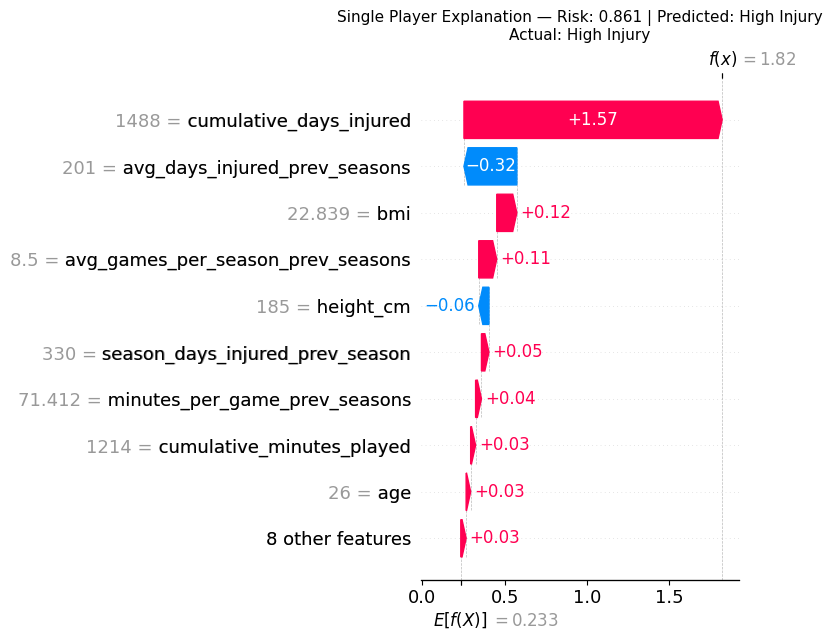

Saved → ../../docs/cycle3_shap_waterfall.png


In [18]:
# Explain one specific High Injury prediction
high_idx   = y_test[y_test == 1].index
sample_idx = X_test.index.get_loc(high_idx[0])   # first actual High Injury player in test set

predicted_prob  = model.predict_proba(X_test_s[sample_idx:sample_idx+1])[0, 1]
predicted_class = model.predict(X_test_s[sample_idx:sample_idx+1])[0]
actual_class    = y_test.iloc[sample_idx]
outcome_names   = {0: 'Low Injury', 1: 'High Injury'}

print(f'Sample index:              {sample_idx}')
print(f'Actual:                    {actual_class} ({outcome_names[actual_class]})')
print(f'Predicted:                 {predicted_class} ({outcome_names[predicted_class]})')
print(f'High Injury probability:   {predicted_prob:.3f}')
print()

# expected_value is the model baseline (average injury risk across training data)
base_val = explainer.expected_value
if isinstance(base_val, (list, np.ndarray)):
    base_val = float(base_val[1])   # positive class baseline

shap_explanation = shap.Explanation(
    values=shap_arr[sample_idx],           # per-feature SHAP contributions for this player
    base_values=base_val,                  # baseline injury risk (average model output)
    data=X_test.values[sample_idx],        # original unscaled feature values for display
    feature_names=feature_cols
)

plt.figure(figsize=(10, 7))
shap.plots.waterfall(shap_explanation, show=False)
plt.title(
    f'Single Player Explanation — Risk: {predicted_prob:.3f} | Predicted: {outcome_names[predicted_class]}\n'
    f'Actual: {outcome_names[actual_class]}',
    fontsize=11
)
plt.tight_layout()
plt.savefig('../../docs/cycle3_shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → ../../docs/cycle3_shap_waterfall.png')


### Observations
- The waterfall traces the prediction from baseline to a final High Injury probability of **0.861** — this player was correctly classified as High Injury
- `cumulative_days_injured` is expected to be the largest single contributor, in line with its dominant global SHAP magnitude (~0.72)
- Medical staff can use this to prioritise interventions: e.g. a player flagged primarily by high `cumulative_days_injured` should have a tailored load-management plan

**Explainable AI (XAI)** is especially important for medical applications: a clinical decision support tool must be transparent to be trusted and adopted. SHAP provides a mathematically rigorous, per-player breakdown of which risk factors drove the prediction, satisfying transparency requirements and enabling actionable insights beyond a simple risk score.

**Limitation:** AUC 0.6710 reflects the fundamental difficulty of injury prediction — many causal factors (training load, match intensity, individual physiology) are unobserved. The model is best used as a risk screening tool alongside clinical judgment, not as a definitive predictor.

## Conclusions

| Feature Category | Key Features (Mean \|SHAP\|) | Direction |
|---|---|---|
| Prior injury (dominant) | cumulative_days_injured (~0.72), avg_days_injured_prev_seasons (~0.15) | Positive → High Risk |
| Physical attributes | bmi (~0.08), height_cm (~0.07), weight_kg (~0.03) | Positive → High Risk (moderate) |
| Career workload | cumulative_games_played (~0.06), avg_games_per_season_prev_seasons (~0.05), cumulative_minutes_played (~0.05) | Positive → High Risk |
| Age | age (~0.06) | Positive → older = higher risk (small) |
| FIFA profile | pace (~0.04), fifa_rating (~0.03), physic (~0.005) | Mixed, marginal |
| Effectively unused | work_rate_numeric (~0.002), position_numeric (0.000), significant_injury_prev_season (0.000) | No signal |

The model learns a **medically coherent but very concentrated** pattern: a single feature, `cumulative_days_injured`, carries the bulk of the signal, with physical attributes, career workload and age providing secondary contributions. Position, work rate and the binary "significant injury" flag were effectively ignored — once continuous injury-history is available, the binary version adds nothing. This validates the model is capturing real signal aligned with sports-medicine literature, while also confirming that injury prediction remains inherently uncertain at AUC 0.6710.